In [27]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Data

array_64_bins = np.array([2177, 6701, 9273, 7605, 6107, 5965, 5711, 5513, 7407, 7012, 2969, 4439, 7153, 6503, 5824, 9839, 15861, 15634, 11026, 8397, 7747, 9556, 8595, 9443, 12157, 12383, 10263, 12270, 13062, 6701, 2234, 0])
array_64_bins_normalized = array_64_bins / np.max(array_64_bins)
x_64_bins = np.arange(len(array_64_bins))


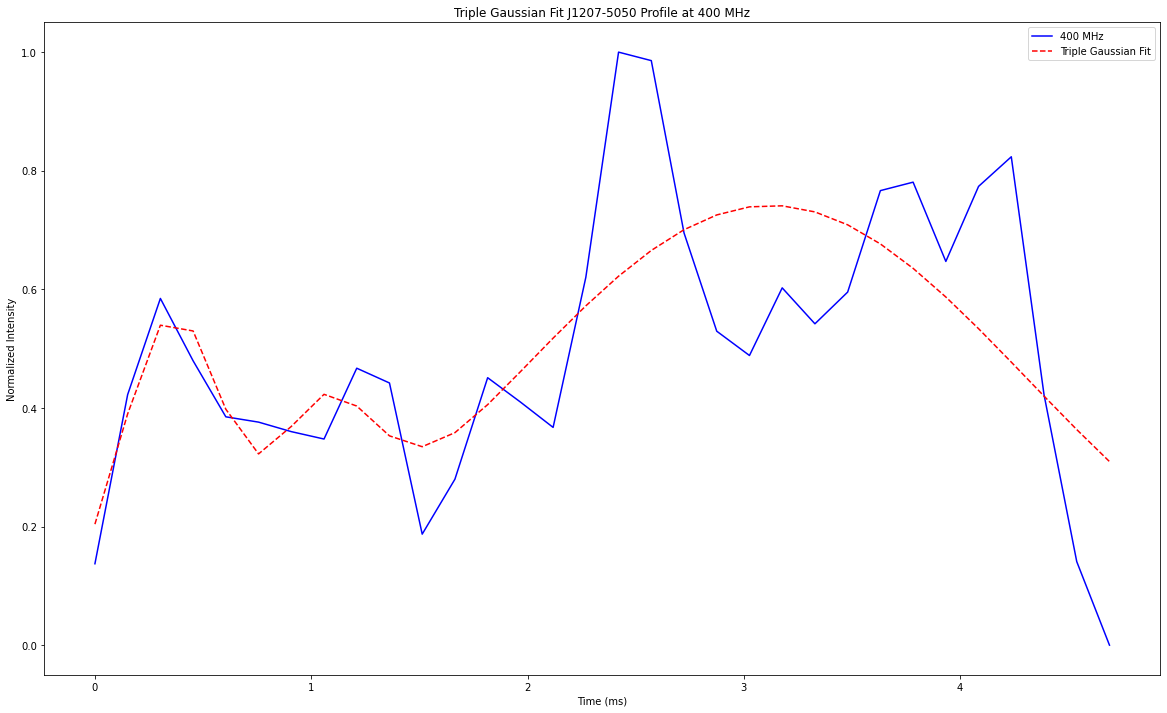


Parameters for J1207-5050 at 400 MHz (Triple Gaussian):
A1 = 95.99744838849193, mu1 = 0.6724024891392935, sigma1 = 0.2893529405877348, FWHM1 = 0.6813741045846473 ms
A2 = -95.73699310971361, mu2 = 0.67302846985222, sigma2 = -0.28825194212129823, FWHM2 = -0.678781451326334 ms
A3 = 0.7416035240499939, mu3 = 3.1236347059239242, sigma3 = 1.1855764139668992, FWHM3 = 2.791819104525165 ms


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert bin numbers to time in ms
x_64_bins_time = np.array(x_64_bins) * (4.842 / 32)

# Define the triple Gaussian function
def triple_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2, A3, mu3, sigma3):
    return (A1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) +
            A2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) +
            A3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)))

# Set initial guesses for A, mu, and sigma for each Gaussian
initial_guesses_64 = [0.6, 0.5, 0.1, 1, 1.5, 0.1, 1, 2.5, 0.1]

# Fit the triple Gaussian model to the 64-bin data (aligned)
popt_64_gauss, _ = curve_fit(triple_gaussian, x_64_bins_time, array_64_bins_normalized, p0=initial_guesses_64, maxfev=1000000000)

# Calculate FWHM for each Gaussian
FWHM1 = 2 * np.sqrt(2 * np.log(2)) * popt_64_gauss[2]
FWHM2 = 2 * np.sqrt(2 * np.log(2)) * popt_64_gauss[5]
FWHM3 = 2 * np.sqrt(2 * np.log(2)) * popt_64_gauss[8]
A2 = 1
# Plotting the results for the 64-bin data
plt.figure(figsize=(20, 12))
plt.plot(x_64_bins_time, array_64_bins_normalized, label='400 MHz', color='blue')
plt.plot(x_64_bins_time, triple_gaussian(x_64_bins_time, *popt_64_gauss), label='Triple Gaussian Fit', color='red', linestyle='--')
plt.title('Triple Gaussian Fit J1207-5050 Profile at 400 MHz')
plt.xlabel('Time (ms)')
plt.ylabel('Normalized Intensity')
plt.legend()
plt.show()

# Print the parameters for the 64-bin data
print("\nParameters for J1207-5050 at 400 MHz (Triple Gaussian):")
print(f"A1 = {popt_64_gauss[0]}, mu1 = {popt_64_gauss[1]}, sigma1 = {popt_64_gauss[2]}, FWHM1 = {FWHM1} ms")
print(f"A2 = {popt_64_gauss[3]}, mu2 = {popt_64_gauss[4]}, sigma2 = {popt_64_gauss[5]}, FWHM2 = {FWHM2} ms")
print(f"A3 = {popt_64_gauss[6]}, mu3 = {popt_64_gauss[7]}, sigma3 = {popt_64_gauss[8]}, FWHM3 = {FWHM3} ms")